# Cervical Screening Check: analysis notebook

This notebook walks through the analysis behind the app, step by step: the data, the leakage problem, how the models were compared, how green each one is, and how the final model does on the locked test set.

The heavy part (nested cross-validation of five models with energy tracking) lives in `scripts/train_evaluate.py` and takes about five minutes. Here I load its saved results so the notebook runs in under a minute. Set `RUN_FULL_PIPELINE = True` below to rerun everything from scratch.

**Outcome:** positive cervical biopsy. **Data:** UCI Cervical Cancer (Risk Factors), 858 women, Caracas, Venezuela (CC BY 4.0).

In [1]:
RUN_FULL_PIPELINE = False   # True reruns the whole training script (about 5 minutes)

import sys, json, warnings
from pathlib import Path

# Works from the notebooks/ folder, the repo root, or Google Colab
try:
    import google.colab  # noqa: F401
    !git clone -q https://github.com/onipayedejohn/cervical-screening-cdss.git
    %cd cervical-screening-cdss
    !pip install -q -r requirements-dev.txt
    ROOT = Path.cwd()
except ImportError:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             confusion_matrix, ConfusionMatrixDisplay)

from cervical_cdss.features import (FEATURES, LABELS, LEAKY_COLUMNS, DROPPED_FOR_QUALITY,
                                    TARGET, load_raw, clean, xy)

pd.set_option("display.width", 160)
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.grid": True,
                     "grid.color": GRID, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": GRID, "axes.titleweight": "bold", "axes.titlelocation": "left"})
print("project root:", ROOT)

project root: /home/claude/cervical-screening-cdss


In [2]:
if RUN_FULL_PIPELINE:
    import runpy
    runpy.run_path(str(ROOT / "scripts" / "train_evaluate.py"), run_name="__main__")

## 1. The raw data

Missing answers are stored as `?` in the original file. Many women chose not to answer the sensitive questions, so I read `?` as missing rather than dropping those women.

In [3]:
raw = load_raw()
print(raw.shape)
raw.head()

(858, 36)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [4]:
df = clean(raw)
print(f"exact duplicate rows removed: {len(raw) - len(df)}  ->  {len(df)} women")
print(f"positive biopsies: {df[TARGET].sum()} ({df[TARGET].mean():.1%})")

exact duplicate rows removed: 23  ->  835 women
positive biopsies: 54 (6.5%)


Only about 6.5% of women have a positive biopsy. That single fact rules out accuracy as a metric: a model that calls everyone negative would be about 94% "accurate" and would miss every case.

In [5]:
print(f"accuracy of predicting 'negative' for everyone: {1 - df[TARGET].mean():.1%}")

accuracy of predicting 'negative' for everyone: 93.5%


## 2. Missing data

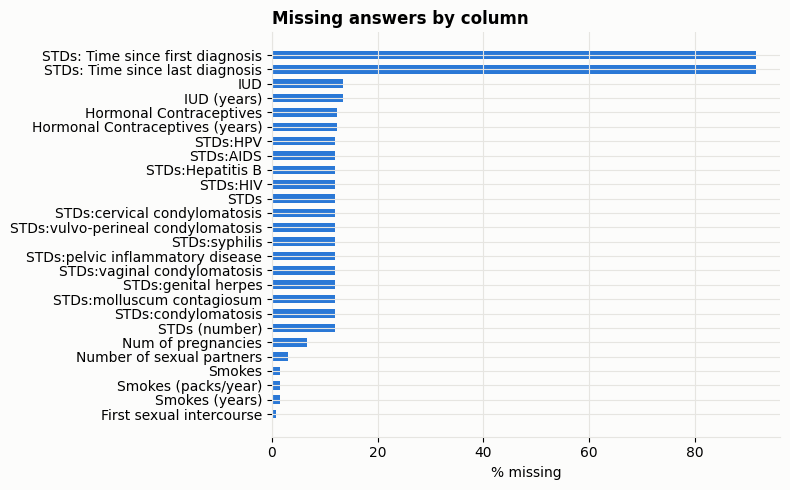

In [6]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(miss.index[::-1], miss.values[::-1] * 100, color=BLUE, height=0.6)
ax.set_xlabel("% missing")
ax.set_title("Missing answers by column")
plt.tight_layout(); plt.show()

Two columns (time since first and last STI diagnosis) are 92% empty, so I dropped them. The rest are missing in blocks: a woman who skipped one sexual-history question usually skipped the whole group. I kept these women, imputed inside the model pipeline, and added missing-value indicators, because *choosing not to answer* can itself carry information.

In [7]:
block = df[["STDs", "STDs (number)", "STDs:HIV", "STDs:condylomatosis"]].isna()
print("women missing all four STI questions together:", block.all(axis=1).sum())
print("women missing only some of them:            ", (block.any(axis=1) & ~block.all(axis=1)).sum())

women missing all four STI questions together: 100
women missing only some of them:             0


## 3. Who is in this dataset?

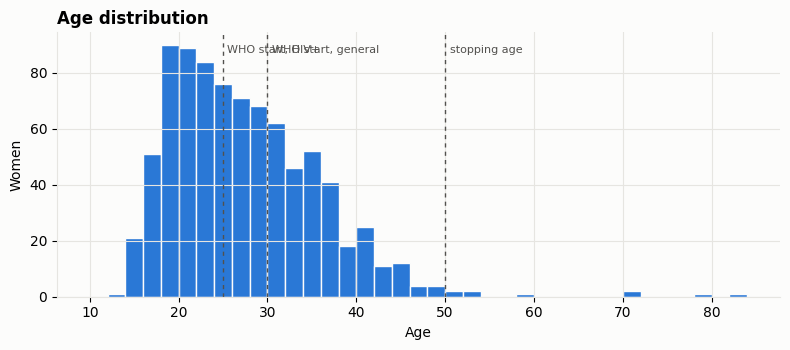

median age 26; under 30: 66%; over 50: 8 women


In [8]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(df["Age"], bins=range(10, 86, 2), color=BLUE, edgecolor=SURFACE)
for age, label in [(25, "WHO start, HIV+"), (30, "WHO start, general"), (50, "stopping age")]:
    ax.axvline(age, color=INK2, ls=(0, (3, 3)), lw=1)
    ax.text(age + 0.5, ax.get_ylim()[1] * 0.92, label, fontsize=8, color=INK2)
ax.set(xlabel="Age", ylabel="Women", title="Age distribution")
plt.tight_layout(); plt.show()
print(f"median age {df.Age.median():.0f}; under 30: {(df.Age < 30).mean():.0%}; over 50: {(df.Age > 50).sum()} women")

This matters more than any modelling choice. Two thirds of these women are younger than the WHO start age for the general population, and only 8 are over 50. Any estimate the model gives for older women is close to a guess.

## 4. The leakage problem

The file contains the results of three examinations done in the same work-up as the biopsy (Hinselmann colposcopy, Schiller's test and cytology), plus columns recording existing diagnoses. A screening tool is used *before* those results exist. Here is how closely they track the outcome:

In [9]:
rows = []
for col in ["Hinselmann", "Schiller", "Citology", "Dx:Cancer", "Dx:CIN", "Dx:HPV", "Dx"]:
    pos = df[df[col] == 1]
    rows.append({"column": col, "women flagged": len(pos),
                 "biopsy positive among them": f"{pos[TARGET].mean():.0%}" if len(pos) else "-",
                 "reason excluded": LEAKY_COLUMNS[col]})
pd.DataFrame(rows)

,column,women flagged,biopsy positive among them,reason excluded
0,Hinselmann,35,71%,colposcopy result from the same work-up as the...
1,Schiller,73,64%,Schiller's iodine test result from the same wo...
2,Citology,43,40%,cytology result from the same work-up
3,Dx:Cancer,18,33%,existing cancer diagnosis; handled by the rule...
4,Dx:CIN,9,33%,existing CIN diagnosis; handled by the rules l...
5,Dx:HPV,18,33%,existing HPV diagnosis recorded alongside the ...
6,Dx,24,29%,any of the diagnoses above


When Schiller's test is positive, most biopsies are positive too. A model given these columns would look excellent while doing nothing useful for screening. I excluded all of them, plus the two mostly empty columns, and kept 13 inputs a nurse can collect by asking questions:

In [10]:
pd.DataFrame({"model input": FEATURES, "label in the app": [LABELS[f] for f in FEATURES]})

,model input,label in the app
0,Age,Age
1,Number of sexual partners,Lifetime sexual partners
2,First sexual intercourse,Age at first sex
3,Num of pregnancies,Pregnancies
4,Smokes (years),Years smoking
5,Smokes (packs/year),Pack-years
6,Hormonal Contraceptives (years),Years on hormonal contraception
7,IUD (years),Years with an IUD
8,STDs (number),Number of past STIs
9,STDs:condylomatosis,History of genital warts


## 5. Split once, lock the test set

Same split as the training script: 25% stratified hold-out, seed 42. The check below confirms it matches the saved files, and that no woman appears in both sets.

In [11]:
dev, test = train_test_split(df, test_size=0.25, stratify=df[TARGET], random_state=42)
saved_dev = pd.read_csv(ROOT / "data/processed/dev.csv")
saved_test = pd.read_csv(ROOT / "data/processed/test.csv")
assert len(dev) == len(saved_dev) and len(test) == len(saved_test)

rows = lambda d: set(map(tuple, d[FEATURES + [TARGET]].fillna(-1).values.tolist()))
print(f"development: {len(dev)} women, {dev[TARGET].sum()} positive")
print(f"test:        {len(test)} women, {test[TARGET].sum()} positive")
print("rows shared between dev and test:", len(rows(dev) & rows(test)))

development: 626 women, 40 positive
test:        209 women, 14 positive
rows shared between dev and test: 0


## 6. A quick look at the inputs by outcome

Median values for women with and without a positive biopsy, on the development set only.

In [12]:
X_dev, y_dev = xy(dev)
summary = X_dev.groupby(y_dev).median().T
summary.columns = ["biopsy negative", "biopsy positive"]
summary.index = [LABELS[i] for i in summary.index]
summary

,biopsy negative,biopsy positive
Age,26.00,25.5
Lifetime sexual partners,2.00,2.0
Age at first sex,17.00,17.0
Pregnancies,2.00,2.0
Years smoking,0.00,0.0
Pack-years,0.00,0.0
Years on hormonal contraception,0.58,0.5
Years with an IUD,0.00,0.0
Number of past STIs,0.00,0.0
History of genital warts,0.00,0.0


The differences are small. That is an early warning: history-taking questions alone will not separate these groups well.

## 7. Comparing five models

Each candidate was tuned and scored with **nested cross-validation** on the development set: an inner 3-fold grid search picks hyperparameters, an outer 5-fold × 5-repeat loop measures performance on data the tuning never saw. Models are ranked by PR-AUC, whose no-skill value equals the prevalence.

In [13]:
comp = pd.read_csv(ROOT / "reports/metrics/model_comparison.csv")
comp[["model", "pr_auc_mean", "pr_auc_std", "roc_auc_mean", "roc_auc_std", "brier_mean", "best_params"]].round(3)

,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,brier_mean,best_params
0,Gradient boosting,0.145,0.078,0.596,0.100,0.165,"{""model__learning_rate"": 0.03, ""model__max_dep..."
1,Random forest,0.135,0.049,0.604,0.084,0.122,"{""model__max_features"": ""sqrt"", ""model__min_sa..."
2,Logistic regression,0.127,0.049,0.579,0.115,0.221,"{""model__C"": 0.01}"
3,SVM (RBF),0.127,0.060,0.507,0.121,0.060,"{""model__C"": 0.1, ""model__gamma"": ""scale""}"
4,Baseline (no skill),0.064,0.000,0.500,0.000,0.060,{}


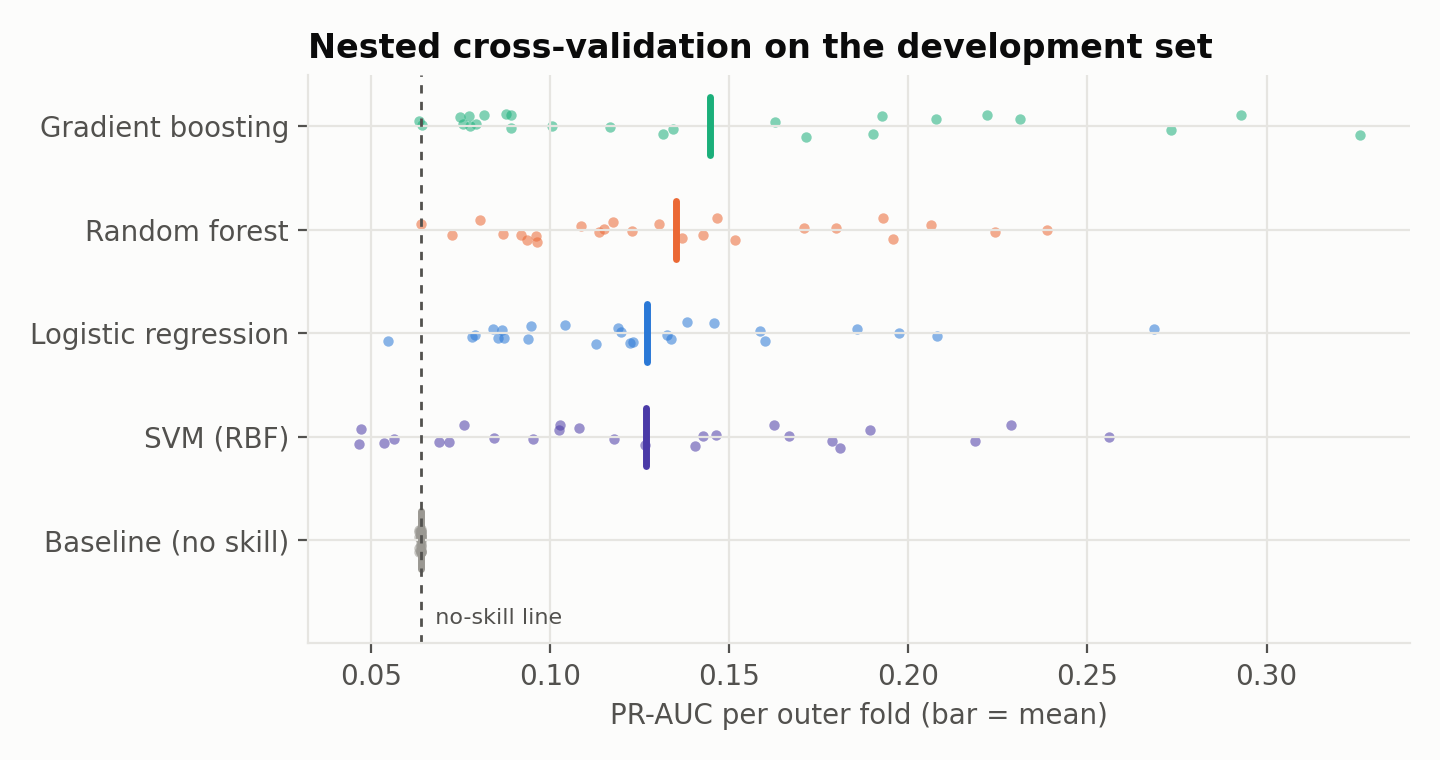

In [14]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "reports/figures/model_comparison.png"), width=720))

(The `best_params` column comes from the 3-fold search used for the comparison. The final refit uses a 5-fold search on the whole development set, which chose a learning rate of 0.1.)

Gradient boosting has the highest mean PR-AUC, but look at the spread across folds: every model overlaps with the others. With 40 positive cases in the development set, the ranking is not something I would defend strongly.

## 8. How green is each model?

I tracked energy with CodeCarbon, using Ghana's grid carbon intensity, for three things: the full nested CV, one final fit, and scoring 1,000 women.

In [15]:
green = comp[["model", "pr_auc_mean", "cv_seconds", "cv_energy_wh", "cv_co2_g",
              "inference_ms_per_1000", "model_size_kb"]].copy()
green["energy vs logistic regression"] = (green["cv_energy_wh"] /
    green.loc[green.model == "Logistic regression", "cv_energy_wh"].item()).round(1).astype(str) + "×"
green.round(4)

,model,pr_auc_mean,cv_seconds,cv_energy_wh,cv_co2_g,inference_ms_per_1000,model_size_kb,energy vs logistic regression
0,Gradient boosting,0.1446,16.8143,0.0761,0.0368,2.0612,82.2432,6.9×
1,Random forest,0.1351,192.6475,0.7220,0.3494,10.7888,1010.2207,65.6×
2,Logistic regression,0.1270,2.2236,0.0110,0.0053,0.4556,3.2197,1.0×
3,SVM (RBF),0.1268,8.1300,0.0314,0.0152,25.5889,123.4502,2.9×
4,Baseline (no skill),0.0639,0.1963,0.0006,0.0003,0.2356,1.8447,0.1×


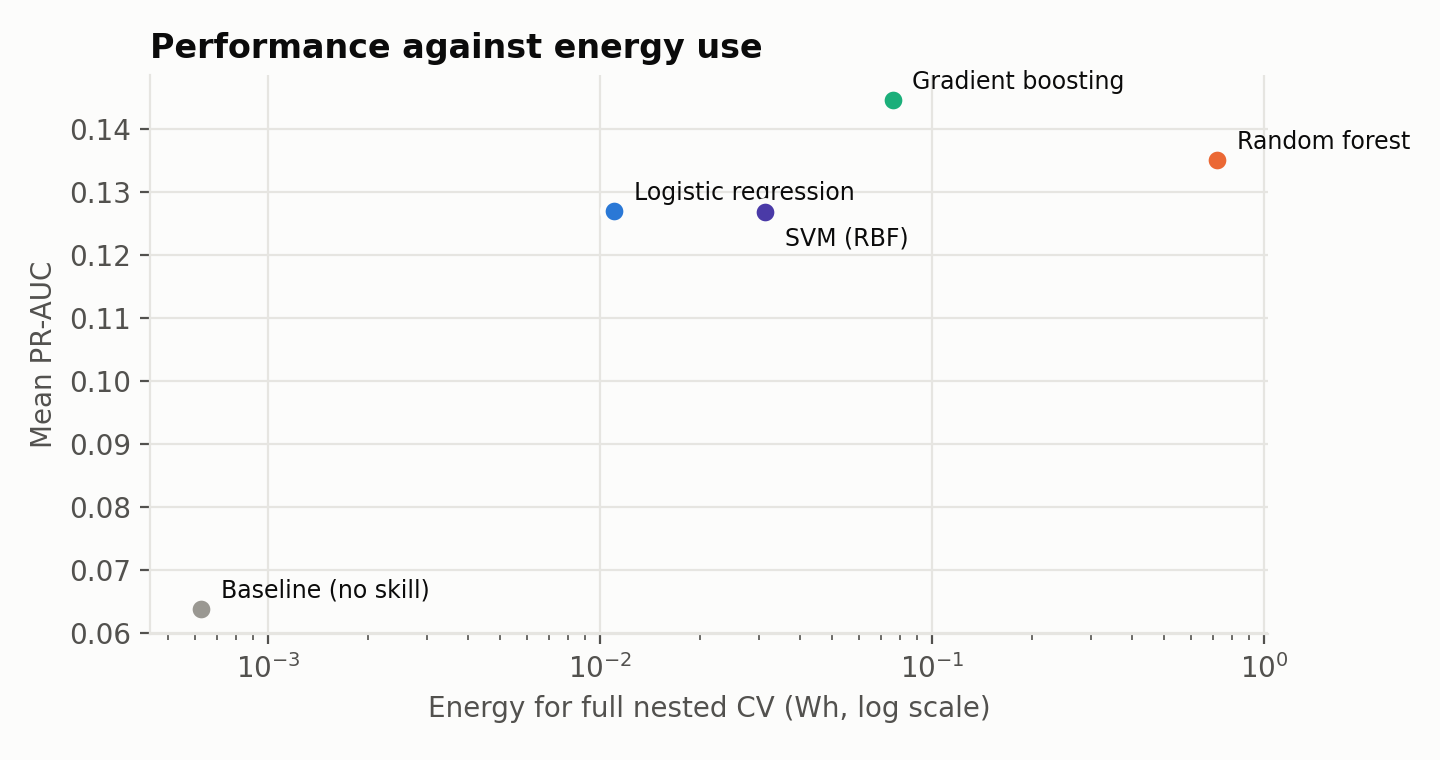

In [16]:
display(Image(filename=str(ROOT / "reports/figures/green_vs_performance.png"), width=720))

The random forest used roughly ten times the energy of gradient boosting and was not better. The selection rule I fixed before seeing results was: highest mean PR-AUC, and if another model is within 0.01, take the greener one. Logistic regression was 0.018 behind, so gradient boosting stayed.

A caveat: this ran on a cloud VM without hardware power counters, so CodeCarbon estimates CPU power. The comparison between models is meaningful; the absolute watt-hours are approximate.

## 9. The final model on the locked test set

The chosen model was refitted on the full development set and calibrated. Its threshold (0.056) was picked from out-of-fold development predictions to reach 80% sensitivity. Nothing below was used to make any decision about the model.

In [17]:
model = joblib.load(ROOT / "models/cervical_risk_model.joblib")
meta = json.loads((ROOT / "models/model_metadata.json").read_text())
X_test, y_test = xy(test)
p = model.predict_proba(X_test)[:, 1]
thr = meta["threshold"]

print(f"ROC-AUC  {roc_auc_score(y_test, p):.3f}")
print(f"PR-AUC   {average_precision_score(y_test, p):.3f}   (no-skill {y_test.mean():.3f})")
print(f"Brier    {brier_score_loss(y_test, p):.4f}  (predicting the prevalence for everyone: {brier_score_loss(y_test, np.full(len(y_test), y_dev.mean())):.4f})")
tn, fp, fn, tp = confusion_matrix(y_test, p >= thr).ravel()
print(f"at threshold {thr:.3f}: sensitivity {tp/(tp+fn):.2f}, specificity {tn/(tn+fp):.2f}, "
      f"PPV {tp/(tp+fp):.2f}, NPV {tn/(tn+fn):.2f}")

ROC-AUC  0.667
PR-AUC   0.116   (no-skill 0.067)
Brier    0.0616  (predicting the prevalence for everyone: 0.0625)
at threshold 0.056: sensitivity 0.86, specificity 0.34, PPV 0.09, NPV 0.97


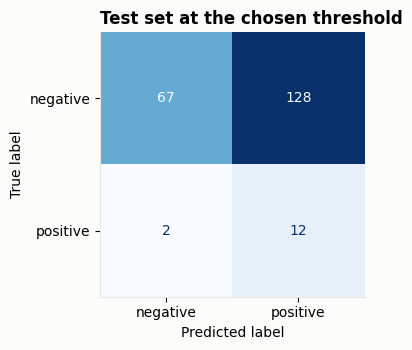

In [18]:
fig, ax = plt.subplots(figsize=(4, 3.6))
ConfusionMatrixDisplay(confusion_matrix(y_test, p >= thr), display_labels=["negative", "positive"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.grid(False); ax.set_title("Test set at the chosen threshold")
plt.tight_layout(); plt.show()

In [19]:
ci = pd.DataFrame(meta["test_ci_95"], index=["2.5%", "97.5%"]).T.round(3)
ci.index.name = "95% bootstrap CI (2,000 resamples)"
ci

,2.5%,97.5%
"95% bootstrap CI (2,000 resamples)",,
roc_auc,0.513,0.800
pr_auc,0.062,0.228
brier,0.036,0.093
sensitivity,0.636,1.000
specificity,0.279,0.409
ppv,0.043,0.135
npv,0.926,1.000


The model catches 12 of the 14 positive cases, but it flags about two thirds of all women to do so. The Brier score is barely better than predicting the average rate for everyone. On its own this is a weak model, and the confidence intervals are wide because 14 positives is a small number.

Where it does help is ranking. Splitting women into three bands (cut points from development out-of-fold predictions):

In [20]:
bands = pd.DataFrame(meta["risk_bands_test"])
bands["observed_rate"] = (bands["observed_rate"] * 100).round(1)
bands.rename(columns={"observed_rate": "positive biopsy rate (%)"})

,band,n,positives,positive biopsy rate (%)
0,Lower,89,2,2.2
1,Average,64,5,7.8
2,Higher,56,7,12.5


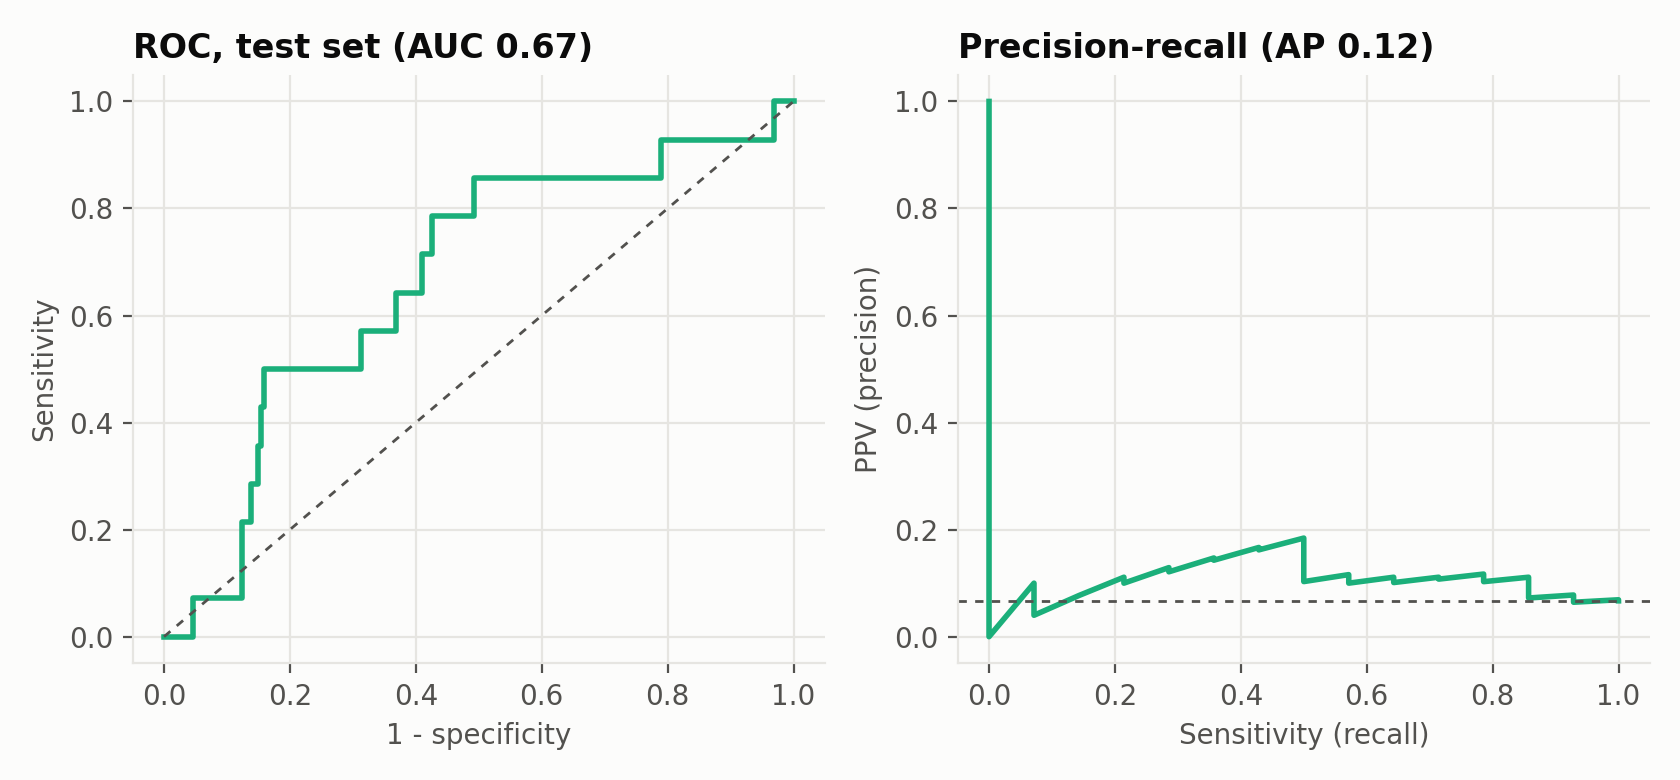

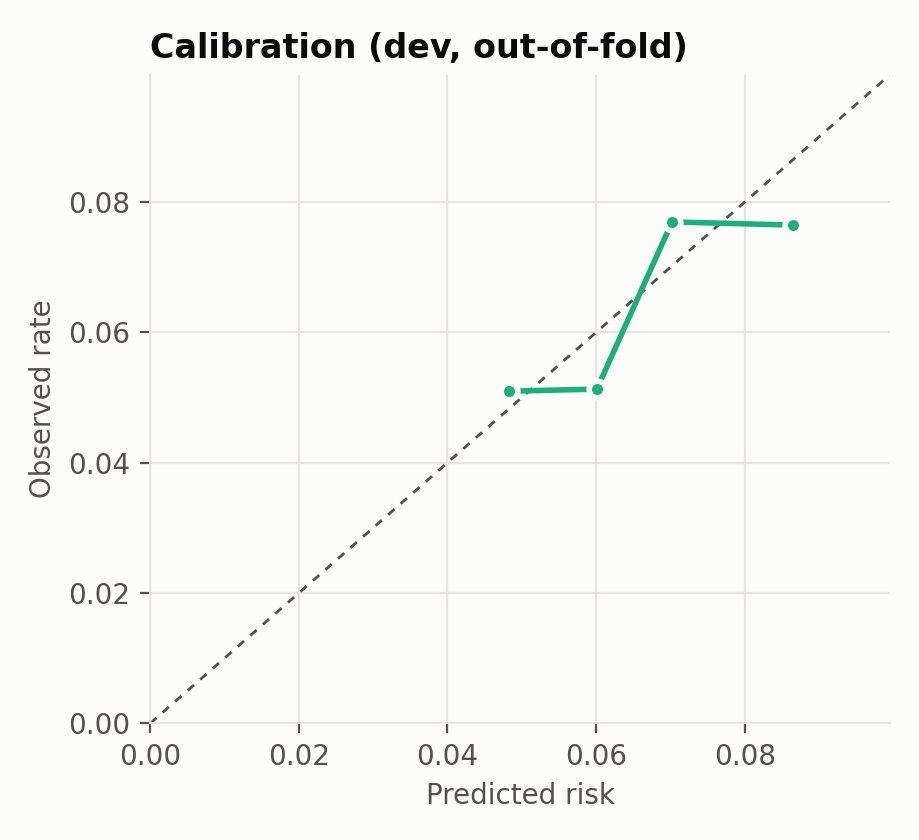

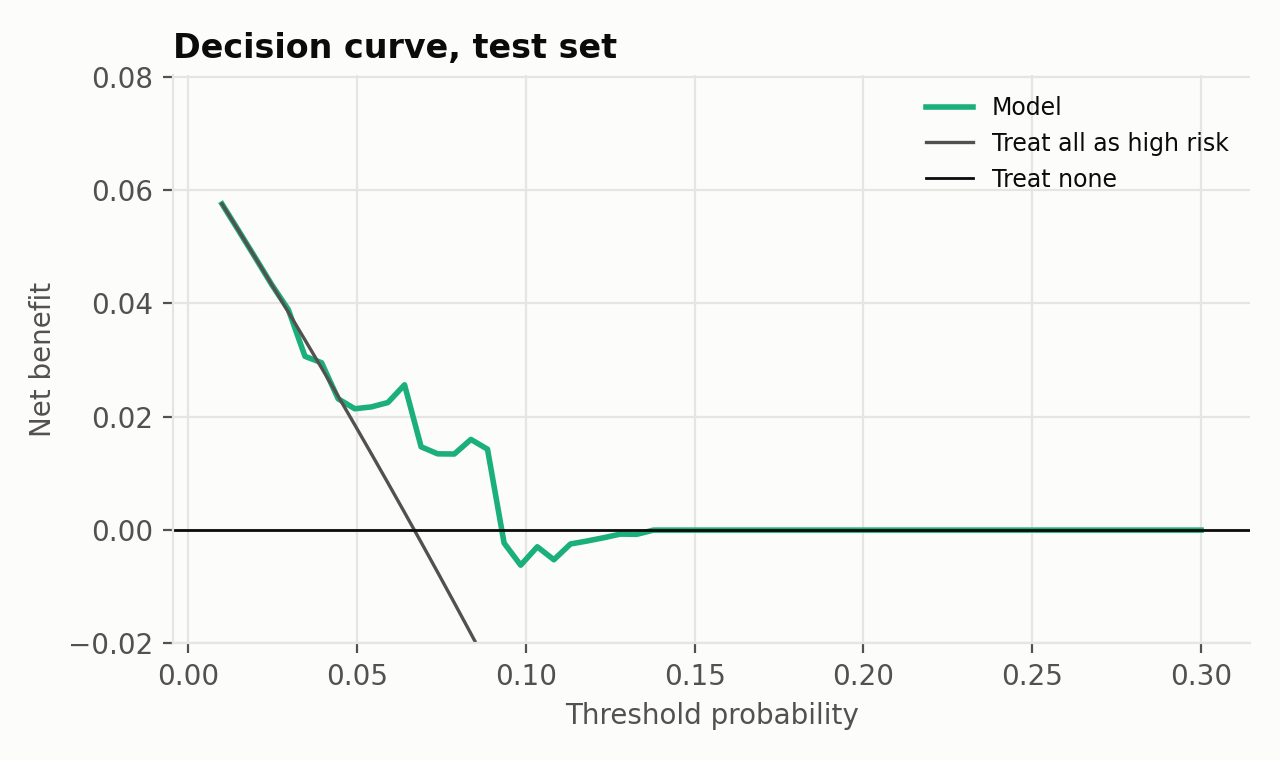

In [21]:
display(Image(filename=str(ROOT / "reports/figures/test_roc_pr.png"), width=760))
display(Image(filename=str(ROOT / "reports/figures/calibration.png"), width=380))
display(Image(filename=str(ROOT / "reports/figures/decision_curve.png"), width=600))

The decision curve shows a small net benefit only for thresholds around 5 to 9%, which is exactly where this model is meant to sit.

## 10. What happens if you let the leakage back in

Same kind of model, same split, but now allowed to see the examination results and prior diagnoses.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

leak_cols = FEATURES + list(LEAKY_COLUMNS)
leaky = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                  ("model", RandomForestClassifier(300, min_samples_leaf=5, class_weight="balanced_subsample",
                                                   random_state=42))])
leaky.fit(dev[leak_cols], dev[TARGET])
pl = leaky.predict_proba(test[leak_cols])[:, 1]
pd.DataFrame({"honest model": [roc_auc_score(y_test, p), average_precision_score(y_test, p)],
              "with leaked columns": [roc_auc_score(y_test, pl), average_precision_score(y_test, pl)]},
             index=["ROC-AUC", "PR-AUC"]).round(3)

,honest model,with leaked columns
ROC-AUC,0.667,0.897
PR-AUC,0.116,0.694


The jump from about 0.67 to about 0.90 is almost entirely the model reading results that come from the same work-up as the biopsy. This is the reason I do not trust the near-perfect scores often reported on this dataset.

## 11. Does it behave differently by age?

Out-of-fold predictions on the development set, split into age bands (from the bias session in the bootcamp).

In [23]:
pd.read_csv(ROOT / "reports/metrics/subgroup_age_dev_oof.csv")

,age_band,n,positives,roc_auc,sensitivity,specificity
0,under 30,414,25,0.579,0.760,0.308
1,30 to 49,206,13,0.586,0.846,0.218
2,50 and over,6,2,0.250,1.000,0.250


Performance is similar for women under 30 and those aged 30 to 49. For women 50 and over there are only 6 women and 2 positives, so no conclusion is possible. That gap is serious for a screening tool, since screening is aimed at women from 30 upwards.

## 12. What the model relies on

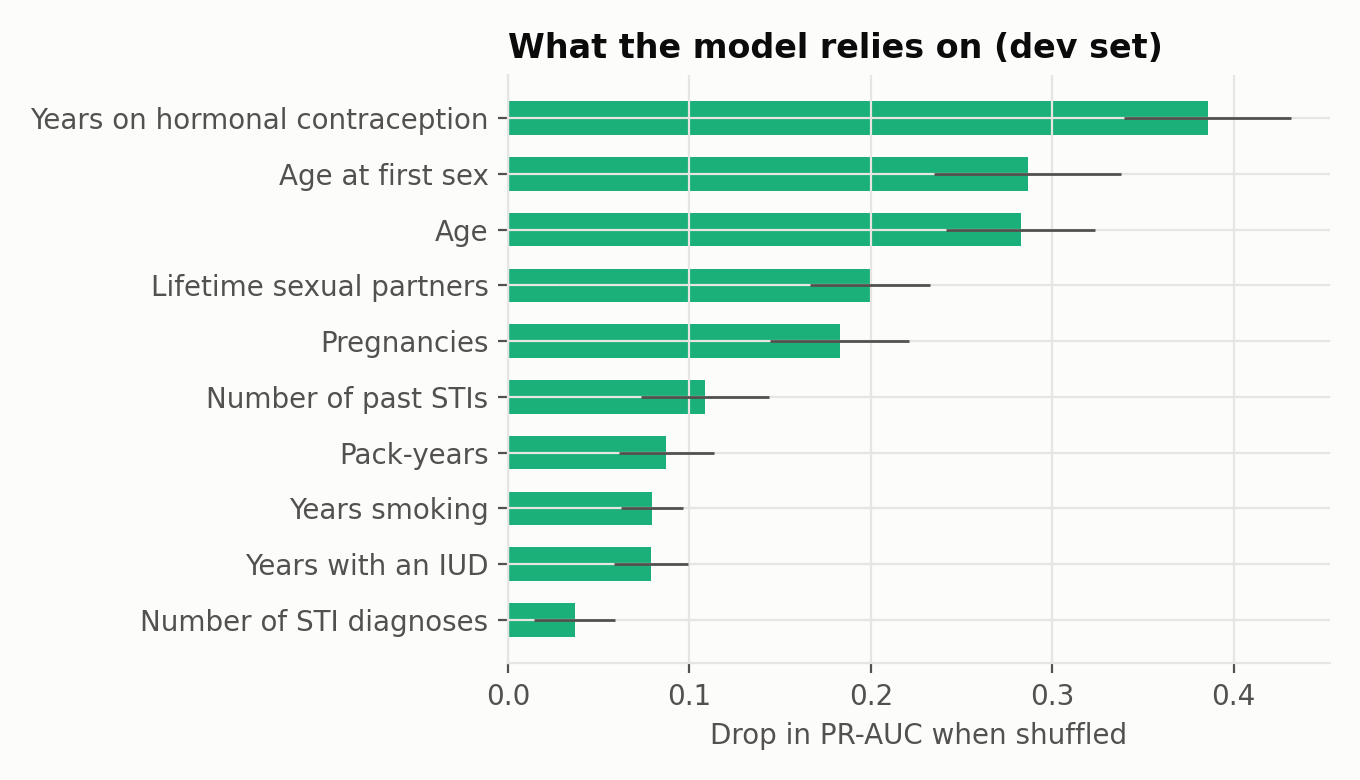

In [24]:
display(Image(filename=str(ROOT / "reports/figures/feature_importance.png"), width=680))

Years on hormonal contraception, age at first sex, age, number of partners and pregnancies carry most of the signal. These are associations in one hospital's data, not causes. HPV infection, the main cause of cervical cancer, is not measured here, and several of these factors are probably standing in for it.

## 13. The rules layer, which makes the actual decisions

Because the model is weak, it never decides anything. The WHO 2021 rules do. A few examples:

In [25]:
from cervical_cdss.rules import ScreeningInput, HIVStatus, ScreenTest, LastResult, assess

cases = {
    "27, HIV negative, never screened": ScreeningInput(age=27, hiv_status=HIVStatus.NEGATIVE),
    "27, living with HIV, never screened": ScreeningInput(age=27, hiv_status=HIVStatus.POSITIVE),
    "42, negative HPV test 4 years ago": ScreeningInput(age=42, hiv_status=HIVStatus.NEGATIVE, ever_screened=True,
        years_since_last_screen=4, last_test_type=ScreenTest.HPV_DNA, last_result=LastResult.NEGATIVE, consecutive_negatives=1),
    "56, two negatives in a row": ScreeningInput(age=56, hiv_status=HIVStatus.NEGATIVE, ever_screened=True,
        years_since_last_screen=4, last_test_type=ScreenTest.HPV_DNA, last_result=LastResult.NEGATIVE, consecutive_negatives=2),
    "38, bleeding after sex": ScreeningInput(age=38, symptoms=["postcoital_bleeding"]),
}
pd.DataFrame([{"woman": k, "decision": (r := assess(v)).headline, "WHO": ", ".join(r.guideline_refs),
               "next step": r.next_step} for k, v in cases.items()])

,woman,decision,WHO,next step
0,"27, HIV negative, never screened",Not yet in the screening age range,Rec. 5,No screening test needed now. Plan the first s...
1,"27, living with HIV, never screened",Due for a first screen,"Rec. 1, Rec. 25, Rec. 27","Offer HPV DNA testing, the preferred primary t..."
2,"42, negative HPV test 4 years ago",Up to date,Rec. 8,No test needed today. Remind her of the next s...
3,"56, two negatives in a row",Screening can stop,Rec. 6,No further routine screening needed unless sym...
4,"38, bleeding after sex",Refer for clinical assessment,,Refer for speculum examination and diagnostic ...


## 14. What I take from this

- Without leakage, history-taking questions give a modest risk signal (test ROC-AUC 0.67, PR-AUC 0.12 against a no-skill 0.07). Good enough to rank women into bands with a roughly five-fold difference in biopsy rate, not good enough to decide anything on its own.
- The guideline rules are the part a clinic could actually use, which is why they sit in front of the model in the app.
- The greener models were not worse. There was no reason to pay ten times the energy for a random forest.
- Before this could be taken seriously it would need external validation on a Ghanaian population, ideally with HPV results, and far more women over 30.

*Research and teaching prototype. Not for clinical use.*